# 04 - MlFlow

## Objectives

The objectives of this notebook are:

1. Train multiple sentiment classification models
2. Compare their predictive performance
3. Track experiments using MLflow
4. Identify the best-performing model

In [65]:
# imports

import warnings
warnings.filterwarnings("ignore")

import time
import mlflow
import mlflow.sklearn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from vaderSentiment.vaderSentiment import (
    SentimentIntensityAnalyzer
)

In [66]:
# set mlflow experiment

mlflow.set_experiment("sentiment-analysis")

# set random seed for reproducibility

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [67]:
df = pd.read_parquet(
    "../data/procerssed_data.parquet"
)

print("Processed data:")
display(df.head())

Processed data:


,review_id,split,rating,text,sentiment,sentiment_label,movie_id,text_raw,text_clean,text_length_original,text_length_raw,text_length_clean,word_count_clean
0,0,train,9,Bromwell High is a cartoon comedy. It ran at t...,pos,1,None,Bromwell High is a cartoon comedy. It ran at t...,bromwell high cartoon comedy ran time program ...,806,806,493,70
1,10000,train,8,Homelessness (or Houselessness as George Carli...,pos,1,None,Homelessness (or Houselessness as George Carli...,homelessness houselessness george carlin state...,2366,2322,1378,208
2,10001,train,10,Brilliant over-acting by Lesley Ann Warren. Be...,pos,1,None,Brilliant over-acting by Lesley Ann Warren. Be...,brilliant acting lesley ann warren best dramat...,841,841,558,84
3,10002,train,7,This is easily the most underrated film inn th...,pos,1,None,This is easily the most underrated film inn th...,easily underrated film inn brook cannon sure f...,663,663,422,66
4,10003,train,8,This is not the typical Mel Brooks film. It wa...,pos,1,None,This is not the typical Mel Brooks film. It wa...,not typical mel brook film much less slapstick...,647,647,349,54


In [68]:
# split data into training and testing sets

train_df = df[
    df["split"] == "train"
]

test_df = df[
    df["split"] == "test"
]

# features for classical ML models
X_train_text = train_df[
    "text_clean"
]

X_test_text = test_df[
    "text_clean"
]

# raw text for VADER
X_train_raw = train_df[
    "text_raw"
]

X_test_raw = test_df[
    "text_raw"
]

# target variable
y_train = train_df[
    "sentiment_label"
]

y_test = test_df[
    "sentiment_label"
]

In [69]:
print('X_train_text:', X_train_text.shape)
print('X_test_text:', X_test_text.shape)

print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

print('y_train unique values:', y_train.unique())

X_train_text: (25000,)
X_test_text: (25000,)
y_train: (25000,)
y_test: (25000,)
y_train unique values: [1 0]


In [70]:
# vectorize text data using TF-IDF

tfidf = TfidfVectorizer(
    max_features=10000, # limit to top 10k features
    ngram_range=(1,2) # include unigrams and bigrams (every word and every pair of consecutive words)
)

X_train_tfidf = tfidf.fit_transform(
    X_train_text
)

X_test_tfidf = tfidf.transform(
    X_test_text
)

print("TF-IDF vectorization:")
print(X_train_tfidf.shape, X_test_tfidf.shape)

TF-IDF vectorization:
(25000, 10000) (25000, 10000)


In [71]:
# define function to evaluate model performance using classification metrics

def evaluate_model(
    y_true,
    y_pred
):

    metrics = {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "precision": precision_score(
            y_true,
            y_pred,
            average="weighted"
        ),

        "recall": recall_score(
            y_true,
            y_pred,
            average="weighted"
        ),

        "f1": f1_score(
            y_true,
            y_pred,
            average="weighted"
        )
    }

    return metrics

In [72]:
# define function to plot confusion matrix

def plot_confusion_matrix_custom(
    y_true,
    y_pred,
    title
):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    fig, ax = plt.subplots(
        figsize=(5,4)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(ax=ax)

    plt.title(title)

    return fig

In [73]:
# results list to store evaluation results for each model

results = []

## VADER Baseline

In [74]:
# initialize VADER sentiment analyzer

analyzer = SentimentIntensityAnalyzer()

In [75]:
# define function to predict sentiment using VADER

def vader_predict(text):

    score = analyzer.polarity_scores(
        text
    )["compound"]

    if score >= 0:
        return 1
    return 0

{'accuracy': 0.69864, 'precision': 0.7233005495391451, 'recall': 0.69864, 'f1': 0.6900834693823299}


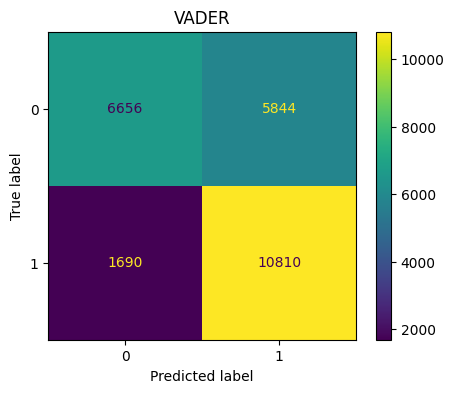

In [76]:
# evaluate VADER on test set

with mlflow.start_run(
    run_name="VADER"
):
    
    start = time.time()

    preds = X_test_raw.apply(
        vader_predict
    )

    end = time.time() - start

    metrics = evaluate_model(
        y_test,
        preds
    )

    for k, v in metrics.items():
        mlflow.log_metric(k, v)

    fig = plot_confusion_matrix_custom(
        y_test,
        preds,
        "VADER"
    )

    mlflow.log_metric(
        "training_time",
        end
    )

    mlflow.log_figure(
        fig,
        "vader_cm.png"
    )

    results.append({
    "Model": "VADER",
    "Accuracy": metrics["accuracy"],
    "Precision": metrics["precision"],
    "Recall": metrics["recall"],
    "F1": metrics["f1"]
    })

    print(metrics)

## Logistic Regression + TF-IDF

2026/06/13 15:43:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 15:43:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


{'accuracy': 0.888, 'precision': 0.8880000397312041, 'recall': 0.888, 'f1': 0.8879999971328001}


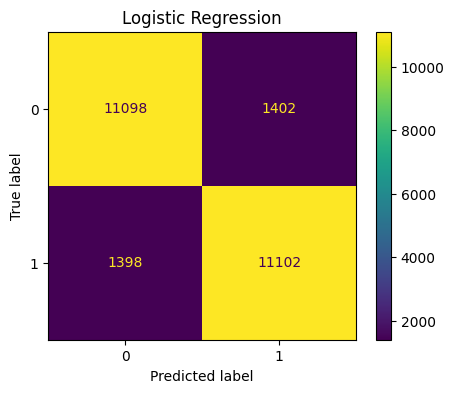

In [77]:
# evaluate Logistic Regression on test set

with mlflow.start_run(
    run_name="LogisticRegression"
):

    model = LogisticRegression(
        random_state=42
    )

    start = time.time()

    model.fit(
        X_train_tfidf,
        y_train
    )

    preds = model.predict(
        X_test_tfidf
    )

    end = time.time() - start

    metrics = evaluate_model(
        y_test,
        preds
    )

    for k, v in metrics.items():
        mlflow.log_metric(k, v)

    mlflow.sklearn.log_model(
        model,
        "model"
    )

    fig = plot_confusion_matrix_custom(
        y_test,
        preds,
        "Logistic Regression"
    )

    mlflow.log_metric(
        "training_time",
        end
    )

    mlflow.log_figure(
        fig,
        "logreg_cm.png"
    )

    results.append({
    "Model": "Logistic Regression",
    "Accuracy": metrics["accuracy"],
    "Precision": metrics["precision"],
    "Recall": metrics["recall"],
    "F1": metrics["f1"]
    })

    print(metrics)

## Linear SVM + TF-IDF

2026/06/13 15:43:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 15:43:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


{'accuracy': 0.8736, 'precision': 0.8736937618575351, 'recall': 0.8736, 'f1': 0.8735920708856753}


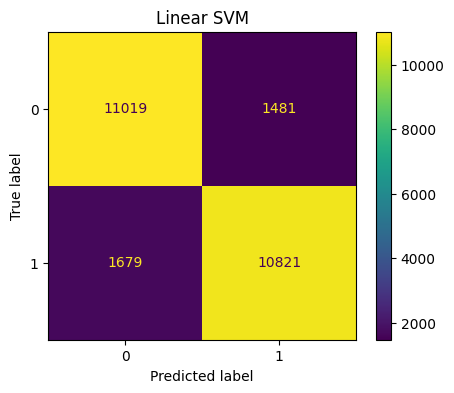

In [78]:
# evaluate Linear SVM on test set

with mlflow.start_run(
    run_name="LinearSVM"
):

    model = LinearSVC(
        random_state=42
    )

    start = time.time()

    model.fit(
        X_train_tfidf,
        y_train
    )

    preds = model.predict(
        X_test_tfidf
    )

    end = time.time() - start

    metrics = evaluate_model(
        y_test,
        preds
    )

    for k, v in metrics.items():
        mlflow.log_metric(k, v)

    mlflow.sklearn.log_model(
        model,
        "model"
    )

    fig = plot_confusion_matrix_custom(
        y_test,
        preds,
        "Linear SVM"
    )

    mlflow.log_metric(
        "training_time",
        end
    )

    mlflow.log_figure(
        fig,
        "linearsvm_cm.png"
    )

    results.append({
    "Model": "Linear SVM",
    "Accuracy": metrics["accuracy"],
    "Precision": metrics["precision"],
    "Recall": metrics["recall"],
    "F1": metrics["f1"]
    })

    print(metrics)

In [79]:
# create results dataframe and display

results_df = pd.DataFrame(
    results
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1
0,VADER,0.69864,0.723301,0.69864,0.690083
1,Logistic Regression,0.88800,0.888000,0.88800,0.888000
2,Linear SVM,0.87360,0.873694,0.87360,0.873592


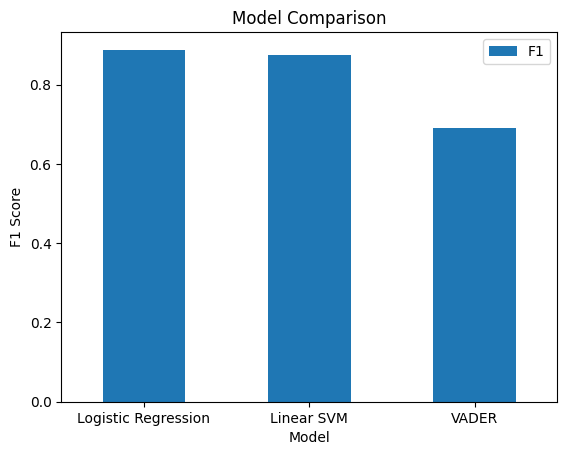

In [80]:
results_df.sort_values(
    by="F1",
    ascending=False
).plot(
    x="Model",
    y="F1",
    kind="bar"
)

plt.title("Model Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=0)

plt.show()

In [81]:
## MLflow dashboard

## Run in terminal in noterbook directory:

## mlflow ui

In [82]:
# Average metrics for each model across all runs

experiment = mlflow.get_experiment_by_name(
    "sentiment-analysis"
)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

runs.head()

summary = (
    runs.groupby("tags.mlflow.runName")
    .agg({
        "metrics.accuracy": "mean",
        "metrics.precision": "mean",
        "metrics.recall": "mean",
        "metrics.f1": "mean",
        "metrics.training_time": "mean"
    })
    .round(3)
)

summary.columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Training Time (s)"
]

summary = summary.reset_index().rename(columns={"tags.mlflow.runName": "Model"})
summary = summary.sort_values(by="F1", ascending=False)
summary = summary.set_index("Model")

print("Average metrics for each model across all runs:")

display(summary)

Average metrics for each model across all runs:


,Accuracy,Precision,Recall,F1,Training Time (s)
Model,,,,,
LogisticRegression,0.888,0.888,0.888,0.888,0.242
LinearSVM,0.874,0.874,0.874,0.874,0.325
VADER,0.699,0.723,0.699,0.690,29.616
